In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "modules"))

In [3]:
import time
import math
import numpy as np
from pyscf import gto

from misc_utils.pyscf_tools import get_integrals_rhf
from misc_utils.pyscf_tools import davidson_restricted_fullci_mask as davidson_pyscf
from misc_utils.matrix_utilities import davidson
from ormas_tools.rasci import Full_CI, RAS_CI

In [152]:
from fci_pec import fci_pec, rasci_pec, hfci_pec
basis = '6-31G(df,pd)'
#R_list = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 
#          1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8]

R_list_short = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
E_rasci, CIC_rasci = rasci_pec(R_list_short, basis=basis)
!mkdir -p 631Gdfpd
np.savez(file="631Gdfpd/H6_pec.npz", 
         R_vals = R_list_short, 
         E_rasci = E_rasci, 
         CIC_rasci = CIC_rasci
        )

n_core = 0
n_act  = 60
n_elec = [3 3]
Constructing CI object...
 ... Done: 8.39 sec.
CI dimension: 1032340
String distribution over occupation groups:
[[   400  16200 171720]
 [ 16200 656100      0]
 [171720      0      0]]
RHF Total Energy: -3.0924847891 Hartree (Time: 0.07 sec)
Integral transformation completed (Time: 0.04 sec)
Davidson diagonalization...
verbose = 0
 ... Done: 132.51 sec.
CI energy: -3.241425562185272
    0  -3.24142556
RHF Total Energy: -3.1380727276 Hartree (Time: 0.07 sec)
Integral transformation completed (Time: 0.04 sec)
Davidson diagonalization...
verbose = 0
 ... Done: 132.61 sec.
CI energy: -3.297569476678629
    1  -3.29756948
RHF Total Energy: -3.1354790683 Hartree (Time: 0.07 sec)
Integral transformation completed (Time: 0.03 sec)
Davidson diagonalization...
verbose = 0
 ... Done: 148.84 sec.
CI energy: -3.308353523460945
    2  -3.30835352
RHF Total Energy: -3.1072990341 Hartree (Time: 0.07 sec)
Integral transformation completed (Time: 0.03 sec)
Davidson

In [165]:
data_STO3G = np.load(file="STO3G/H6_pec.npz")
data_631G = np.load(file="631G/H6_pec.npz")
data_631Gss = np.load(file="631Gss/H6_pec.npz")
data_631Gdfpd = np.load(file="631Gdfpd/H6_pec.npz")

R_list = data_STO3G['R_vals']
R_list_short = data_631Gdfpd['R_vals']

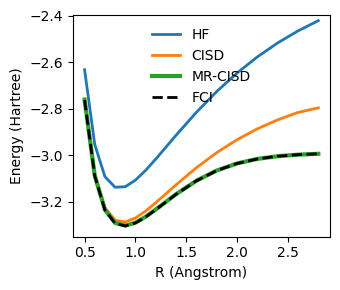

In [182]:
from matplotlib import pyplot as plt
data = data_631Gss
fig, ax = plt.subplots(figsize=(3.5,3))
ax.plot(R_list, data["E_hf"], lw=2, label='HF')
ax.plot(R_list, data["E_hfci2"], lw=2, label='CISD')
ax.plot(R_list, data["E_rasci"], lw=3, label='MR-CISD')
ax.plot(R_list, data["E_fci"], color="black", ls="dashed", lw=2, label='FCI')

ax.legend(frameon=False)
ax.set_ylim([-3.35,-2.4])
ax.set_xlabel("R (Angstrom)")
ax.set_ylabel("Energy (Hartree)")

plt.tight_layout()
plt.show()

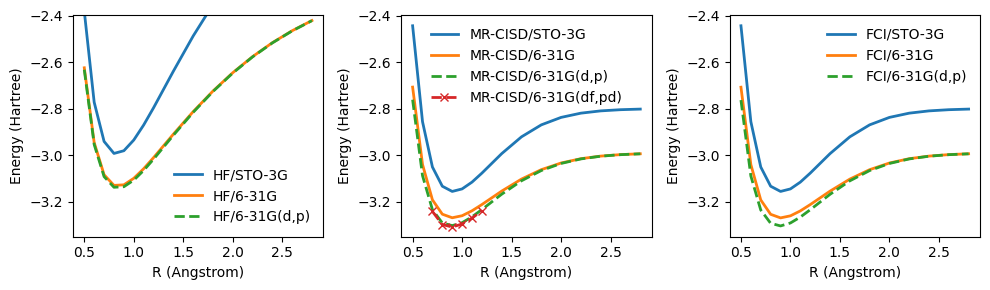

In [183]:
fig, ax = plt.subplots(ncols=3, figsize=(10,3))
ax[0].plot(R_list, data_STO3G["E_hf"], lw=2, label="HF/STO-3G")
ax[0].plot(R_list, data_631G["E_hf"], lw=2, label="HF/6-31G")
ax[0].plot(R_list, data_631Gss["E_hf"], lw=2, ls="dashed", label="HF/6-31G(d,p)")

ax[1].plot(R_list, data_STO3G["E_rasci"], lw=2, label="MR-CISD/STO-3G")
ax[1].plot(R_list, data_631G["E_rasci"], lw=2, label="MR-CISD/6-31G")
ax[1].plot(R_list, data_631Gss["E_rasci"], lw=2, ls="dashed", label="MR-CISD/6-31G(d,p)")
ax[1].plot(R_list_short, data_631Gdfpd["E_rasci"], lw=2, ls="dashed", label="MR-CISD/6-31G(df,pd)", marker='x')

ax[2].plot(R_list, data_STO3G["E_fci"], lw=2, label="FCI/STO-3G")
ax[2].plot(R_list, data_631G["E_fci"], lw=2, label="FCI/6-31G")
ax[2].plot(R_list, data_631Gss["E_fci"], lw=2, ls="dashed", label="FCI/6-31G(d,p)")

for i in range(len(ax)):
    ax[i].legend(frameon=False)
    ax[i].set_ylim([-3.35,-2.4])
    ax[i].set_xlabel("R (Angstrom)")
    ax[i].set_ylabel("Energy (Hartree)")

plt.tight_layout()
plt.show()

1.0
